# LangChain Smarter Search & LlamaIndex Advanced Retrievers

This notebook is organized into **two independent teaching tracks** that share one small corpus and one embedding model:

- **Section A — Building smarter search with LangChain (context retrieval & compression)**  
  Dense search, lexical BM25, hybrid fusion, then **contextual compression** so downstream LLM prompts stay focused.

- **Section B — Building advanced retrievers in LlamaIndex**  
  Nodes, vector + BM25 retrievers, **reciprocal rank fusion**, and **metadata-filtered** vector retrieval.

All instructional text is in **English**. Run cells **from top to bottom** on a fresh kernel. After changing packages, **restart the kernel** and rerun the install cell.

**Prerequisites:** comfortable Python/Jupyter; basic idea of embeddings; internet once for Hugging Face model cache (`sentence-transformers/all-MiniLM-L6-v2`) unless already local.


## Shared setup — Python environment

The two sections use the **same kernel** so Section B can reuse the `docs` list and `QUERY` string you define in Section A.

This block installs **LangChain** (including `langchain-classic` for ensemble + contextual compression), **community integrations**, **LlamaIndex**, and scientific plotting helpers.


In [7]:
# Shared Step S1 — Install packages into this kernel
import subprocess
import sys

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-U",
        "langchain",
        "langchain-community",
        "langchain-classic",
        "langchain-huggingface",
        "langchain-core",
        "sentence-transformers",
        "faiss-cpu",
        "rank_bm25",
        "pandas",
        "matplotlib",
        "llama-index",
        "llama-index-embeddings-huggingface",
    ]
)
print("Done. Restart the kernel if the next cell reports missing modules, then rerun S1–S2.")


Done. Restart the kernel if the next cell reports missing modules, then rerun S1–S2.


In [8]:
# Shared Step S2 — Imports used in both sections
import textwrap
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["font.size"] = 10

print("Shared libraries ready (pandas, matplotlib, display).")


Shared libraries ready (pandas, matplotlib, display).


---

# Section A — Building smarter search with LangChain (context retrieval & compression)

## A.0 What you will implement

1. A **toy corpus** as LangChain `Document` objects (metadata included for later reuse in Section B).  
2. A **dense-only** baseline with **FAISS** + Sentence-Transformers embeddings.  
3. A **BM25** lexical retriever on the same corpus.  
4. A **hybrid** retriever using LangChain’s **`EnsembleRetriever`** (weighted fusion of ranked lists).  
5. **Contextual compression**: wrap the dense retriever with an **embedding-based filter** so weakly related chunks are dropped before they become LLM context.

Throughout Section A, ask: *does the retrieved set match what a human subject-matter expert would pick first?* Retrieval quality is usually the bottleneck in RAG, not the generator.


## A.1 Theory — From bags of words to dense vectors

**Lexical models (e.g., BM25)** treat text as a multiset of tokens. They excel when users remember **exact wording**: regulation numbers, equipment names, rare chemical symbols. They struggle when users **paraphrase** or use synonyms not present in the document.

**Dense retrieval** maps queries and passages to vectors in $\mathbb{R}^d$ and ranks by geometric proximity (cosine similarity, inner product, or Euclidean distance depending on indexing choices). It captures **semantic similarity**: “crew must show drill records” can match “evidence of drills related to gas fuel leakage” even with little token overlap.

**Failure modes to remember**

- Dense models may ignore **critical rare tokens** if the surrounding context pulls the vector toward a generic topic.  
- Lexical models may return **nothing useful** if the query uses different vocabulary than the source.  
- Both return **top-k** lists; *k* always includes the “best available” items, which may still be **wrong** if the corpus is small or ambiguous.

Section A shows these behaviours on a deliberately mixed corpus (maritime safety text plus one off-topic Python paragraph).


## A.2 Theory — LangChain objects you will touch

- **`Document`**: a text payload (`page_content`) plus optional **`metadata`** (dict). Metadata is not embedded automatically; you choose when to filter on it (Section B does this explicitly in LlamaIndex).  
- **`Embeddings`**: a callable model that turns strings into vectors. Here we use **`HuggingFaceEmbeddings`** for a small, local Sentence-Transformer.  
- **`VectorStore` / FAISS wrapper**: stores vectors and supports similarity queries.  
- **`BaseRetriever`**: anything implementing `invoke(query) -> list[Document]`. Retrievers compose: hybrid fusion and contextual compression are **wrappers** around another retriever.

This “everything is a retriever” idea is what makes LangChain convenient for experimentation.


## A.3 Step — Define the lab query string

We fix one natural-language question for the whole notebook so tables and plots stay comparable across cells.

**Tip:** change `QUERY` later and rerun Section A (and Section B) to see how sensitive each method is to wording.


In [9]:
QUERY = "What should crew prove about gas fuel emergencies during inspections?"
print("QUERY =", repr(QUERY))


QUERY = 'What should crew prove about gas fuel emergencies during inspections?'


## A.4 Step — Build LangChain `Document` objects

We load six short passages: five maritime / gas-fuel themed, one about Python (off-topic noise). Each row becomes one `Document` with `doc_id` and coarse `topic` metadata.

**Design choice:** one paragraph per `Document` keeps BM25 statistics and dense vectors aligned at the same granularity for teaching. Production systems usually **chunk** long PDFs first (see Section B for chunking with LlamaIndex).


In [10]:
from langchain_core.documents import Document

RAW_PASSAGES = [
    "The IGF Code requires that personnel on gas-fuelled ships receive training appropriate to their duties, including familiarization with fuel properties and emergency procedures.",
    "Before bunkering LNG, the ship should complete a checklist covering hose connections, communication protocols, and spill response equipment readiness.",
    "LNG boil-off gas may be used as fuel on modern carriers; engine manufacturers publish limits on methane slip and cylinder lubrication adjustments.",
    "The Port State Control officer may ask for evidence of drills related to gas fuel leakage on the main deck and in machinery spaces.",
    "Python list comprehensions provide a concise way to build lists, for example squares = [x*x for x in range(10)].",
    "For cargo tanks, inert gas systems reduce oxygen levels; operators monitor oxygen percentage and maintain positive tank pressure during loading.",
]

docs = [
    Document(
        page_content=textwrap.shorten(p, width=400, placeholder=" …"),
        metadata={"doc_id": i, "topic": "maritime" if i != 4 else "python"},
    )
    for i, p in enumerate(RAW_PASSAGES)
]
print(f"Loaded {len(docs)} documents.")


Loaded 6 documents.


In [11]:
corpus_df = pd.DataFrame(
    [
        {
            "doc_id": d.metadata["doc_id"],
            "topic": d.metadata["topic"],
            "preview": d.page_content[:90] + "…",
        }
        for d in docs
    ]
)
corpus_df


,doc_id,topic,preview
0,0,maritime,The IGF Code requires that personnel on gas-fu...
1,1,maritime,"Before bunkering LNG, the ship should complete..."
2,2,maritime,LNG boil-off gas may be used as fuel on modern...
3,3,maritime,The Port State Control officer may ask for evi...
4,4,python,Python list comprehensions provide a concise w...
5,5,maritime,"For cargo tanks, inert gas systems reduce oxyg..."


## A.5 Step — Visualize document lengths

Retrieval scores are **not automatically comparable** across passages of very different lengths. BM25 uses length normalization; dense models can still be biased by redundant wording.

The bar chart is a sanity check: if one passage is ten times longer than the rest, interpret rank changes carefully.


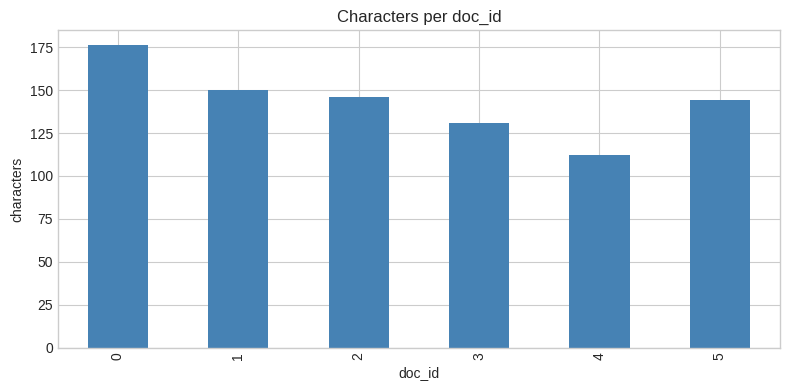

In [12]:
lengths = pd.Series([len(d.page_content) for d in docs], name="chars")
ax = lengths.plot.bar(color="steelblue", title="Characters per doc_id")
ax.set_xlabel("doc_id")
ax.set_ylabel("characters")
plt.tight_layout()
plt.show()


## A.6 Theory — Dense retrieval with FAISS (LangChain wrapper)

**FAISS** (Facebook AI Similarity Search) builds data structures for **approximate nearest neighbour** search in high dimensions. LangChain’s `FAISS.from_documents` embeds each document, inserts vectors into an index, and exposes `similarity_search` / `as_retriever`.

**Distance vs similarity:** the default LangChain FAISS path often reports an **L2 distance**—lower means closer. Always read the docstring for your exact `distance_strategy` when you move beyond this lab.

**Limitation:** dense retrieval returns the *k closest vectors*, not the *k true facts*. If nothing in the corpus answers the question, you still get k “least wrong” neighbours.


In [13]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
embeddings


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4985.56it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [14]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(docs, embeddings)
dense_retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
print("FAISS index built; dense_retriever returns k=4 documents.")


FAISS index built; dense_retriever returns k=4 documents.


In [15]:
baseline_docs = dense_retriever.invoke(QUERY)

pd.DataFrame(
    {
        "rank": range(1, len(baseline_docs) + 1),
        "doc_id": [d.metadata.get("doc_id") for d in baseline_docs],
        "topic": [d.metadata.get("topic") for d in baseline_docs],
        "preview": [d.page_content[:100] + "…" for d in baseline_docs],
    }
)


,rank,doc_id,topic,preview
0,1,3,maritime,The Port State Control officer may ask for evi...
1,2,0,maritime,The IGF Code requires that personnel on gas-fu...
2,3,1,maritime,"Before bunkering LNG, the ship should complete..."
3,4,5,maritime,"For cargo tanks, inert gas systems reduce oxyg..."


## A.7 Step — Inspect raw FAISS distances (dense scores)

Calling `similarity_search_with_score` attaches a numeric **distance** next to each hit. Beginners often skip this and only read prose previews; the numbers make it obvious when the model is **barely** separating two passages.


In [16]:
pairs = vectorstore.similarity_search_with_score(QUERY, k=4)
score_rows = []
for rank, (doc, dist) in enumerate(pairs, start=1):
    score_rows.append(
        {
            "rank": rank,
            "doc_id": doc.metadata.get("doc_id"),
            "faiss_distance": float(dist),
            "preview": doc.page_content[:80] + "…",
        }
    )

score_df = pd.DataFrame(score_rows)
display(score_df)


,rank,doc_id,faiss_distance,preview
0,1,3,0.745314,The Port State Control officer may ask for evi...
1,2,0,0.985742,The IGF Code requires that personnel on gas-fu...
2,3,1,1.044654,"Before bunkering LNG, the ship should complete..."
3,4,5,1.274591,"For cargo tanks, inert gas systems reduce oxyg..."


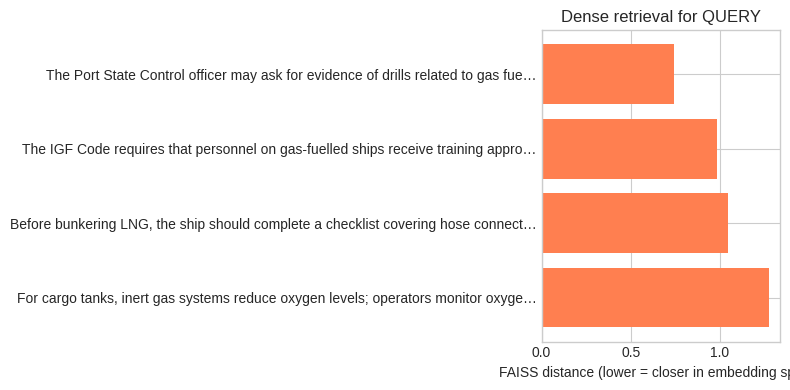

In [17]:
plt.barh(score_df["preview"], score_df["faiss_distance"], color="coral")
plt.xlabel("FAISS distance (lower = closer in embedding space)")
plt.title("Dense retrieval for QUERY")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## A.8 Theory — BM25 in one paragraph

**Okapi BM25** ranks documents by a weighted sum of query term frequencies with **sublinear saturation** (extra occurrences matter less and less) and a **length normalization** penalty so long documents do not dominate only because they repeat words.

Intuition: BM25 is a strong baseline for **keyword-heavy** operational text (checklists, equipment IDs, regulatory citations). It is blind to **synonyms** unless both forms appear in the corpus.

LangChain exposes BM25 through **`BM25Retriever.from_documents`**, which tokenizes each `Document.page_content` and builds an inverted index in memory.


In [18]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(docs)
bm25_retriever.k = 4
print("BM25 retriever ready (k=4).")


BM25 retriever ready (k=4).


In [19]:
bm25_docs = bm25_retriever.invoke(QUERY)

pd.DataFrame(
    {
        "rank": range(1, len(bm25_docs) + 1),
        "doc_id": [d.metadata.get("doc_id") for d in bm25_docs],
        "topic": [d.metadata.get("topic") for d in bm25_docs],
        "preview": [d.page_content[:100] + "…" for d in bm25_docs],
    }
)


,rank,doc_id,topic,preview
0,1,1,maritime,"Before bunkering LNG, the ship should complete..."
1,2,5,maritime,"For cargo tanks, inert gas systems reduce oxyg..."
2,3,4,python,Python list comprehensions provide a concise w...
3,4,3,maritime,The Port State Control officer may ask for evi...


## A.9 Step — Compare dense vs BM25 rankings visually

When the two orderings **diverge**, hybrid methods have room to improve: one retriever may surface a passage the other buried below rank *k*.

The bar chart plots **rank** (lower is better) per `doc_id`; missing bars mean “not in top-k”.


,dense_topk_order,bm25_topk_order
0,3,1
1,0,5
2,1,4
3,5,3


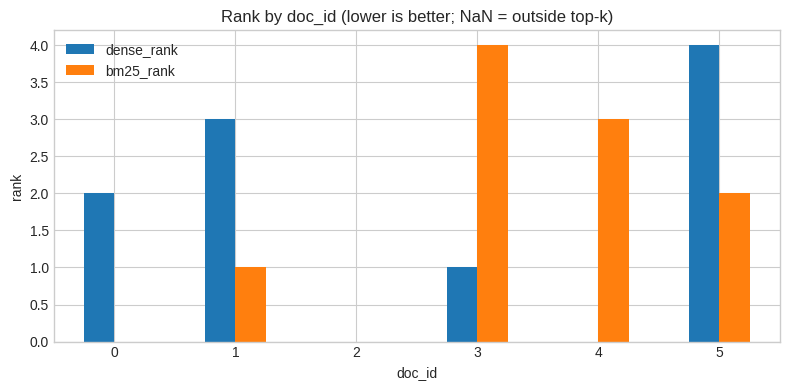

In [20]:
dense_ids = [d.metadata["doc_id"] for d in baseline_docs]
bm25_ids = [d.metadata["doc_id"] for d in bm25_docs]

display(pd.DataFrame({"dense_topk_order": dense_ids, "bm25_topk_order": bm25_ids}))

all_ids = sorted({d.metadata["doc_id"] for d in docs})
dense_rank = {i: dense_ids.index(i) + 1 if i in dense_ids else np.nan for i in all_ids}
bm25_rank = {i: bm25_ids.index(i) + 1 if i in bm25_ids else np.nan for i in all_ids}

wide = pd.DataFrame(
    {"doc_id": all_ids, "dense_rank": [dense_rank[i] for i in all_ids], "bm25_rank": [bm25_rank[i] for i in all_ids]}
).set_index("doc_id")

wide.plot(kind="bar", rot=0, title="Rank by doc_id (lower is better; NaN = outside top-k)")
plt.ylabel("rank")
plt.tight_layout()
plt.show()


## A.10 Theory — Hybrid retrieval with `EnsembleRetriever`

**Hybrid search** usually means combining **lexical** and **dense** signals. LangChain’s **`EnsembleRetriever`** runs multiple retrievers, collects their ranked lists, and merges them using **weighted reciprocal rank fusion** (RRF-style): contributions decay like $1/(\text{rank} + c)$ so a document that is mediocre in both lists can still outrank a document that is first in one list and absent in the other.

**Weights:** `weights=[w_bm25, w_dense]` must be non-negative; LangChain normalizes them internally. They express **prior trust** in each retriever, not strict probabilities.

**When to use:** heterogeneous user queries (sometimes exact codes, sometimes conceptual questions); noisy OCR text (lexical can help); multilingual settings where one retriever is more stable.

**Caveat:** you pay **latency** proportional to the number of child retrievers unless you parallelize at the application layer.


In [21]:
from langchain_classic.retrievers import EnsembleRetriever

hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
    weights=[0.45, 0.55],
)

hybrid_docs = hybrid_retriever.invoke(QUERY)

pd.DataFrame(
    {
        "rank": range(1, len(hybrid_docs) + 1),
        "doc_id": [d.metadata.get("doc_id") for d in hybrid_docs],
        "topic": [d.metadata.get("topic") for d in hybrid_docs],
        "preview": [d.page_content[:100] + "…" for d in hybrid_docs],
    }
)


,rank,doc_id,topic,preview
0,1,1,maritime,"Before bunkering LNG, the ship should complete..."
1,2,3,maritime,The Port State Control officer may ask for evi...
2,3,5,maritime,"For cargo tanks, inert gas systems reduce oxyg..."
3,4,0,maritime,The IGF Code requires that personnel on gas-fu...
4,5,4,python,Python list comprehensions provide a concise w...


## A.11 Theory — Two different meanings of “context” in retrieval

**Industry usage 1 — Contextualized *indexing* (sometimes called “contextual retrieval”):**  
Before embedding a chunk, prepend or otherwise attach **document-level context** (title, section path, auto-generated summary) so the embedding encodes *where the snippet lives*. Anthropic popularized this pattern for reducing “ambiguous chunk” errors in large corpora.

**LangChain usage 2 — Contextual *compression*:**  
After retrieval, run a **compressor** that **removes or shortens** low-value passages relative to the **current query**. Examples: `EmbeddingsFilter`, LLM-powered extractors, or length trimmers.

This notebook implements **(2)** with `EmbeddingsFilter` so you do **not** need a paid chat API. The compressor scores each candidate passage against the query embedding and keeps only those above a similarity threshold—turning “always return k chunks” into “return *up to* k *relevant* chunks”.


## A.12 Step — Build a contextual compression retriever

Pipeline: **`dense_retriever` → `EmbeddingsFilter` → shorter list`**.

Watch the printed **count** of returned documents versus the baseline dense top-k run.


In [22]:
from langchain_classic.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import EmbeddingsFilter

compressor = EmbeddingsFilter(embeddings=embeddings, similarity_threshold=0.42)
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=dense_retriever,
)

compressed_docs = compression_retriever.invoke(QUERY)
print(f"Dense baseline returned k={len(baseline_docs)}; compression returned k={len(compressed_docs)}")


Dense baseline returned k=4; compression returned k=3


In [23]:
pd.DataFrame(
    {
        "rank": range(1, len(compressed_docs) + 1),
        "doc_id": [d.metadata.get("doc_id") for d in compressed_docs],
        "preview": [d.page_content[:120] + "…" for d in compressed_docs],
    }
)


,rank,doc_id,preview
0,1,3,The Port State Control officer may ask for evi...
1,2,0,The IGF Code requires that personnel on gas-fu...
2,3,1,"Before bunkering LNG, the ship should complete..."


## A.13 Step — Sweep the compression threshold (precision vs recall)

**Higher threshold** → fewer passages pass the filter (**higher precision**, risk of **empty** context).  
**Lower threshold** → closer to the original top-k (**higher recall**, risk of **distractor** paragraphs in the LLM prompt).

The line plot shows how many chunks survive as you move the threshold—useful when tuning RAG cost and hallucination risk.


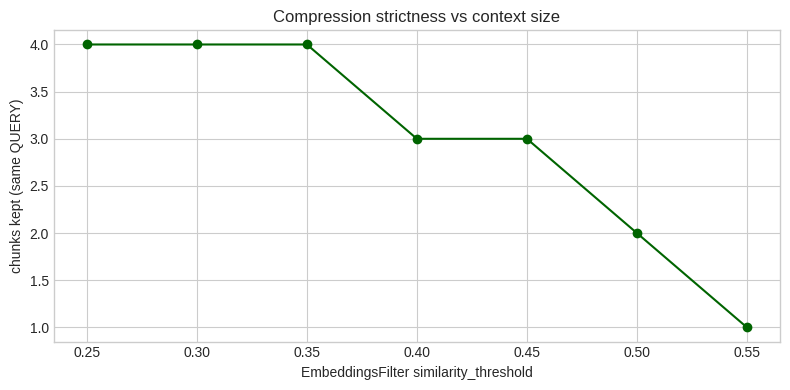

In [24]:
thresholds = np.linspace(0.25, 0.55, 7)
counts = []
for t in thresholds:
    comp = EmbeddingsFilter(embeddings=embeddings, similarity_threshold=float(t))
    cr = ContextualCompressionRetriever(base_compressor=comp, base_retriever=dense_retriever)
    counts.append(len(cr.invoke(QUERY)))

plt.plot(thresholds, counts, marker="o", color="darkgreen")
plt.xlabel("EmbeddingsFilter similarity_threshold")
plt.ylabel("chunks kept (same QUERY)")
plt.title("Compression strictness vs context size")
plt.tight_layout()
plt.show()


### End of Section A (checkpoint)

You should now have: `docs`, `QUERY`, `embeddings`, `vectorstore`, `dense_retriever`, `bm25_retriever`, `hybrid_retriever`, and `compression_retriever` in memory.

**Section B** reuses `docs` and `QUERY` but switches to LlamaIndex’s **`Node`**, **`VectorStoreIndex`**, and fusion retriever APIs.


---

# Section B — Building advanced retrievers in LlamaIndex

## B.0 What you will implement

1. **Parse** the same LangChain `docs` into LlamaIndex **`Document`** objects, then **split** them into **`Node`** chunks (`SentenceSplitter`).  
2. Build a **`VectorStoreIndex`** and a **dense retriever** (`as_retriever`).  
3. Attach a **`BM25Retriever`** over the same `nodes`.  
4. Combine both with **`QueryFusionRetriever`** using **`RECIPROCAL_RANK`** fusion and `num_queries=1` (no extra LLM-generated query variants in this lab).  
5. Apply **`MetadataFilters`** so vector search only sees `topic == "maritime"`—a common production pattern (collections, tenants, sensitivity labels).

LlamaIndex encourages you to think in **graphs of components** (index, retriever, query engine, postprocessors). Here we stay at the **retriever** layer for clarity.


## B.1 Theory — Documents, nodes, and indexes

- **`Document` (LlamaIndex)** wraps free text plus metadata, similar in spirit to LangChain’s `Document`.  
- **`Node`**: the **atomic retrieval unit** after chunking. One source `Document` often becomes **many** nodes. Metadata can be inherited or enriched per node.  
- **`VectorStoreIndex`**: embeds nodes (via `Settings.embed_model`), stores vectors, and supports retrievers, query engines, and rerankers downstream.

**Why chunk?** Embeddings summarize **local** context. Paragraph-sized (or sentence-window) chunks usually trade off **retrieval precision** against **answer completeness**. Too small → missing context; too large → diluted vectors and noisy hits.

**Mock LLM:** `QueryFusionRetriever` resolves an LLM from `Settings.llm` when `num_queries > 1`. We set **`MockLLM`** so the notebook runs without API keys while keeping the door open for multi-query experiments later.


## B.2 Theory — Reciprocal Rank Fusion (RRF) at a high level

Suppose retriever A ranks passage $x$ first and passage $y$ tenth, while retriever B ranks $y$ second and $x$ not in the top list. **Score-level fusion** is awkward because BM25 scores and cosine similarities are on incomparable scales.

**RRF** instead uses **ranks**: each list contributes terms like $1/(k + \text{rank})$ (implementation constants vary). Passages that appear **early in multiple lists** accumulate mass and float to the top.

LlamaIndex’s **`QueryFusionRetriever`** implements several fusion modes; we use **`RECIPROCAL_RANK`** with **`num_queries=1`** so only the user query drives retrieval—**no** auxiliary LLM calls—while still merging **BM25** and **dense** rankings.


In [25]:
%pip install llama-index-retrievers-bm25

Note: you may need to restart the kernel to use updated packages.


In [26]:
from llama_index.core import Document as LIDocument, Settings, VectorStoreIndex
from llama_index.core.llms.mock import MockLLM
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.retrievers import QueryFusionRetriever
from llama_index.core.retrievers.fusion_retriever import FUSION_MODES
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.retrievers.bm25 import BM25Retriever

Settings.llm = MockLLM()
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")
print("LlamaIndex Settings: embed model configured; MockLLM attached for fusion compatibility.")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8387.14it/s]


LlamaIndex Settings: embed model configured; MockLLM attached for fusion compatibility.


## B.3 Step — Chunk into `Node` objects

We reuse `docs` from Section A so both frameworks index **identical text**. The splitter introduces **multiple nodes per doc_id** when a passage is longer than `chunk_size` characters—watch for repeated `doc_id` values in later tables.


In [27]:
splitter = SentenceSplitter(chunk_size=220, chunk_overlap=40)

li_documents = [LIDocument(text=d.page_content, metadata=dict(d.metadata)) for d in docs]
nodes = splitter.get_nodes_from_documents(li_documents)

print(f"Source documents: {len(li_documents)}  →  nodes: {len(nodes)}")


Source documents: 6  →  nodes: 6


In [28]:
node_overview = pd.DataFrame(
    [
        {
            "node_idx": i,
            "doc_id": n.metadata.get("doc_id"),
            "chars": len(n.get_content()),
            "preview": n.get_content()[:70].replace("\n", " ") + "…",
        }
        for i, n in enumerate(nodes)
    ]
)
node_overview.head(12)


,node_idx,doc_id,chars,preview
0,0,0,176,The IGF Code requires that personnel on gas-fu...
1,1,1,150,"Before bunkering LNG, the ship should complete..."
2,2,2,146,LNG boil-off gas may be used as fuel on modern...
3,3,3,131,The Port State Control officer may ask for evi...
4,4,4,112,Python list comprehensions provide a concise w...
5,5,5,144,"For cargo tanks, inert gas systems reduce oxyg..."


## B.4 Step — Dense retriever from `VectorStoreIndex`

`VectorStoreIndex.from_documents` / `from_nodes` materializes embeddings. `as_retriever(similarity_top_k=…)` returns **`NodeWithScore`** objects: the text lives in `node`, the retriever’s confidence in `score` (interpretation depends on the vector store backend).


In [29]:
index = VectorStoreIndex(nodes)
li_dense = index.as_retriever(similarity_top_k=5)
print("VectorStoreIndex ready; li_dense uses similarity_top_k=5.")


VectorStoreIndex ready; li_dense uses similarity_top_k=5.


In [30]:
li_dense_nodes = li_dense.retrieve(QUERY)

li_dense_rows = []
for rank, n in enumerate(li_dense_nodes, start=1):
    li_dense_rows.append(
        {
            "rank": rank,
            "score": float(n.score or 0.0),
            "doc_id": n.node.metadata.get("doc_id"),
            "preview": n.node.get_content()[:100].replace("\n", " ") + "…",
        }
    )

pd.DataFrame(li_dense_rows)


,rank,score,doc_id,preview
0,1,0.599038,3,The Port State Control officer may ask for evi...
1,2,0.446747,1,"Before bunkering LNG, the ship should complete..."
2,3,0.441431,0,The IGF Code requires that personnel on gas-fu...
3,4,0.364706,5,"For cargo tanks, inert gas systems reduce oxyg..."
4,5,0.318874,2,LNG boil-off gas may be used as fuel on modern...


## B.5 Step — BM25 retriever on the same nodes

This is the LlamaIndex-native BM25 path. It should behave similarly to LangChain’s BM25 **at the node granularity**, not at the original six-document granularity—another reason chunking choices matter when you compare frameworks numerically.


In [31]:
li_bm25 = BM25Retriever.from_defaults(nodes=nodes, similarity_top_k=5)

li_bm25_nodes = li_bm25.retrieve(QUERY)

pd.DataFrame(
    {
        "rank": range(1, len(li_bm25_nodes) + 1),
        "score": [float(n.score or 0.0) for n in li_bm25_nodes],
        "doc_id": [n.node.metadata.get("doc_id") for n in li_bm25_nodes],
        "preview": [n.node.get_content()[:100].replace("\n", " ") + "…" for n in li_bm25_nodes],
    }
)


,rank,score,doc_id,preview
0,1,1.049634,0,The IGF Code requires that personnel on gas-fu...
1,2,0.760190,5,"For cargo tanks, inert gas systems reduce oxyg..."
2,3,0.618599,1,"Before bunkering LNG, the ship should complete..."
3,4,0.455775,3,The Port State Control officer may ask for evi...
4,5,0.435257,2,LNG boil-off gas may be used as fuel on modern...


## B.6 Step — `QueryFusionRetriever` with reciprocal rank fusion

We pass **`[li_dense, li_bm25]`**, set **`num_queries=1`** (only the original query; no LLM query rewriting), **`use_async=False`** (simple synchronous execution inside Jupyter), and **`mode=FUSION_MODES.RECIPROCAL_RANK`**.

The resulting **`fused_rrf_score`** is an internal fused ranking score—use it **relatively** within this run, not as an absolute calibrated probability.


In [32]:
fusion_retriever = QueryFusionRetriever(
    [li_dense, li_bm25],
    num_queries=1,
    mode=FUSION_MODES.RECIPROCAL_RANK,
    use_async=False,
    similarity_top_k=5,
)

fused_nodes = fusion_retriever.retrieve(QUERY)

fused_df = pd.DataFrame(
    {
        "rank": range(1, len(fused_nodes) + 1),
        "fused_rrf_score": [float(n.score or 0.0) for n in fused_nodes],
        "doc_id": [n.node.metadata.get("doc_id") for n in fused_nodes],
        "preview": [n.node.get_content()[:100].replace("\n", " ") + "…" for n in fused_nodes],
    }
)
fused_df


,rank,fused_rrf_score,doc_id,preview
0,1,0.032796,0,The IGF Code requires that personnel on gas-fu...
1,2,0.032540,3,The Port State Control officer may ask for evi...
2,3,0.032522,1,"Before bunkering LNG, the ship should complete..."
3,4,0.032266,5,"For cargo tanks, inert gas systems reduce oxyg..."
4,5,0.031250,2,LNG boil-off gas may be used as fuel on modern...


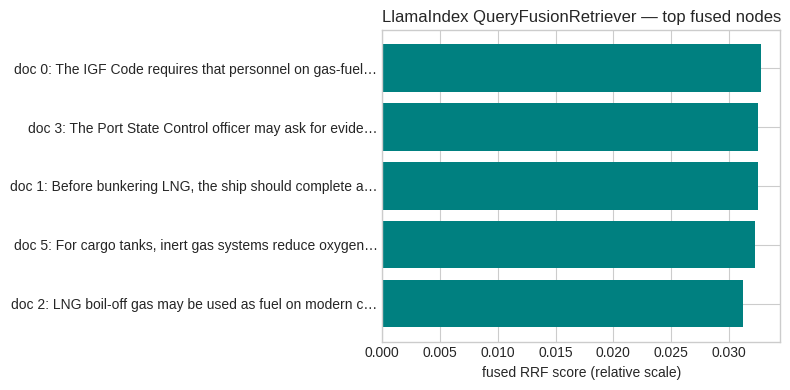

In [33]:
labels = fused_df.apply(lambda r: f"doc {r['doc_id']}: {r['preview'][:48]}…", axis=1)
plt.barh(labels, fused_df["fused_rrf_score"], color="teal")
plt.xlabel("fused RRF score (relative scale)")
plt.title("LlamaIndex QueryFusionRetriever — top fused nodes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## B.7 Theory — Metadata filters as a retrieval “guardrail”

Many corpora mix **classes** of documents: policies vs chat logs vs code. **Metadata filtering** restricts the candidate set **before** vector scoring (exact behaviour depends on the vector store; LlamaIndex passes filters through to compatible backends).

This differs from post-hoc “delete bad hits”: you **never score** filtered-out items, which is useful for **authorization** (user may only search their tenant) and for **topic routing**.

**Trade-off:** aggressive filters improve precision but can return **empty** results if metadata is wrong or incomplete—plan fallbacks (e.g., relax filters, show “no results in this collection”).


## B.8 Step — Vector retriever with `MetadataFilters`

We keep the same `QUERY` but ask the index to consider only nodes whose `topic` metadata equals **`maritime`**. The Python tutorial passage (`doc_id == 4`) should be excluded **unless** chunking or metadata inheritance mislabels a node—inspect the table critically.


In [ ]:
from llama_index.core.vector_stores import MetadataFilter, MetadataFilters

maritime_only = index.as_retriever(
    similarity_top_k=5,
    filters=MetadataFilters(filters=[MetadataFilter(key="topic", value="maritime")]),
)

mf_nodes = maritime_only.retrieve(QUERY)

pd.DataFrame(
    {
        "rank": range(1, len(mf_nodes) + 1),
        "doc_id": [n.node.metadata.get("doc_id") for n in mf_nodes],
        "topic": [n.node.metadata.get("topic") for n in mf_nodes],
        "preview": [n.node.get_content()[:100].replace("\n", " ") + "…" for n in mf_nodes],
    }
)


## B.9 Lab wrap-up — connect the two sections

| Idea | Section A (LangChain) | Section B (LlamaIndex) |
|------|---------------------|-------------------------|
| Lexical vs dense | BM25 vs FAISS retrievers | `BM25Retriever` vs `VectorStoreIndex.as_retriever` |
| Hybrid / fusion | `EnsembleRetriever` | `QueryFusionRetriever` + RRF |
| Context control | `ContextualCompressionRetriever` + `EmbeddingsFilter` | Metadata filters + (optional) postprocessors / rerankers not shown here |

**Self-check questions**

1. Did hybrid or fusion **change the top hit** versus dense-only? Why might that help a user or hurt them?  
2. Did compression **remove** a passage you still wanted? How would you change `similarity_threshold` or base `k`?  
3. How did **node-level** retrieval in LlamaIndex differ from **document-level** lists in Section A?

### Optional extensions

- Set `num_queries>1` on `QueryFusionRetriever` and replace `MockLLM` with a local model via `llama-index-llms-ollama` or HuggingFace LLM integration to study **query rewriting**.  
- Add a **`SentenceTransformerRerank`** postprocessor on fused results.  
- Index a real PDF from the course materials and repeat the same diagnostic plots.

**End of notebook.**
